In [1]:
pip install pytrends matplotlib pandas seaborn plotly

   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   -------- ------------------------------- 2.1/9.9 MB 11.7 MB/s eta 0:00:01
   ---------------- ----------------------- 4.2/9.9 MB 10.9 MB/s eta 0:00:01
   ---------------------- ----------------- 5.5/9.9 MB 9.1 MB/s eta 0:00:01
   -------------------------- ------------- 6.6/9.9 MB 8.2 MB/s eta 0:00:01
   ----------------------------- ---------- 7.3/9.9 MB 7.3 MB/s eta 0:00:01
   ------------------------------- -------- 7.9/9.9 MB 6.7 MB/s eta 0:00:01
   -------------------------------- ------- 8.1/9.9 MB 6.2 MB/s eta 0:00:01
   ---------------------------------- ----- 8.7/9.9 MB 5.3 MB/s eta 0:00:01
   ------------------------------------ --- 8.9/9.9 MB 4.9 MB/s eta 0:00:01
   ------------------------------------- -- 9.2/9.9 MB 4.6 MB/s eta 0:00:01
   ---------------------------------------  9.7/9.9 MB 4.2 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 4.0 MB/s  0:00:02
   -----------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from pytrends.request import TrendReq

# setup pytrend library and keyword define

In [5]:
pytrends = TrendReq(hl = 'en-US', tz = 360)
keyword = "cloud computing"

# DATA REQUEST

In [6]:
pytrends.build_payload([keyword], cat=0,timeframe ='today 12-m', geo='', gprop='')

# country wise interest

In [7]:
region_data = pytrends.interest_by_region()
region_data = region_data.sort_values(by = keyword, ascending = False).head(15)

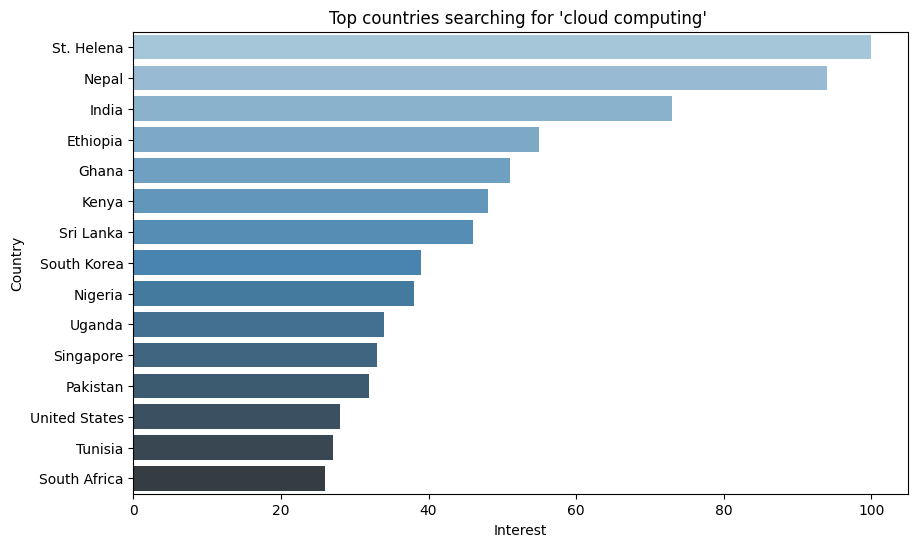

In [8]:
plt.figure(figsize = (10,6))
sns.barplot(x = region_data[keyword], y = region_data.index,hue = region_data.index, palette = "Blues_d",legend = False)
plt.title(f"Top countries searching for '{keyword}' ")
plt.xlabel("Interest")
plt.ylabel("Country")
plt.show()

# World Map 

C:\Users\sanga\AppData\Local\Temp\ipykernel_20344\911520200.py:1: DeprecationWarning:

The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.



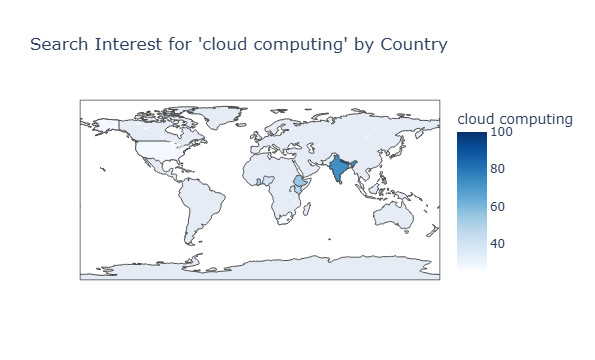

In [13]:
fig = px.choropleth(
    region_data,
    locations='geoName',
    locationmode='country names',
    color=keyword,
    title=f"Search Interest for '{keyword}' by Country"
)

fig.update_layout(
    coloraxis=dict(colorscale='Blues')
)

fig.show()


# Time wise Interest

In [15]:
time_df = pytrends.interest_over_time()

C:\Users\sanga\anaconda3\envs\tfenv\lib\site-packages\pytrends\request.py:260: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



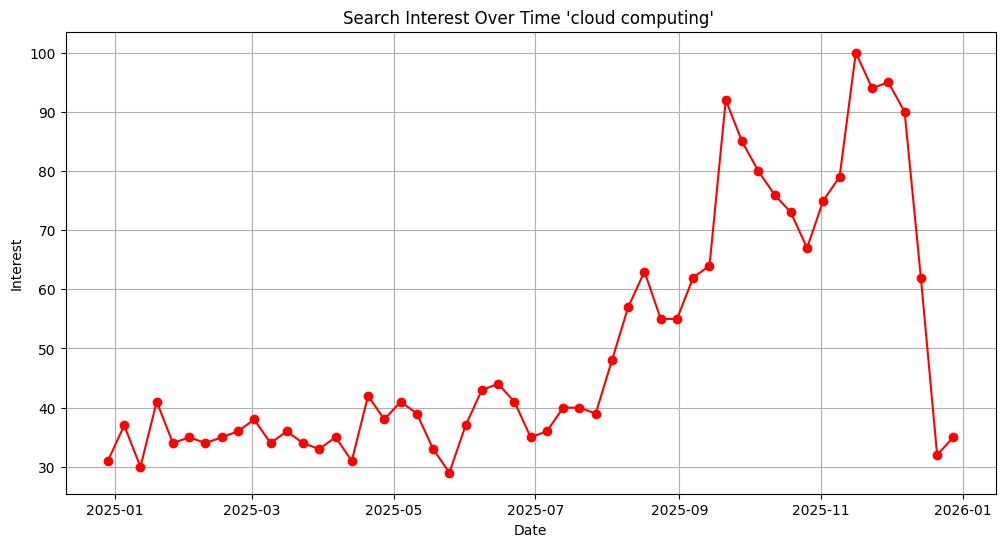

In [17]:
plt.figure(figsize=(12,6))
plt.plot(time_df.index, time_df[keyword], marker = 'o', color='red')
plt.title(f"Search Interest Over Time '{keyword}' ")
plt.xlabel("Date")
plt.ylabel("Interest")
plt.grid(True)
plt.show()

# Multiple Keywords Compare

In [18]:
kw_list = ["cloud computing", "data science", "machine learning"]
pytrends.build_payload(kw_list, cat = 0, timeframe = 'today 12-m',geo ='',gprop ='')

C:\Users\sanga\anaconda3\envs\tfenv\lib\site-packages\pytrends\request.py:260: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



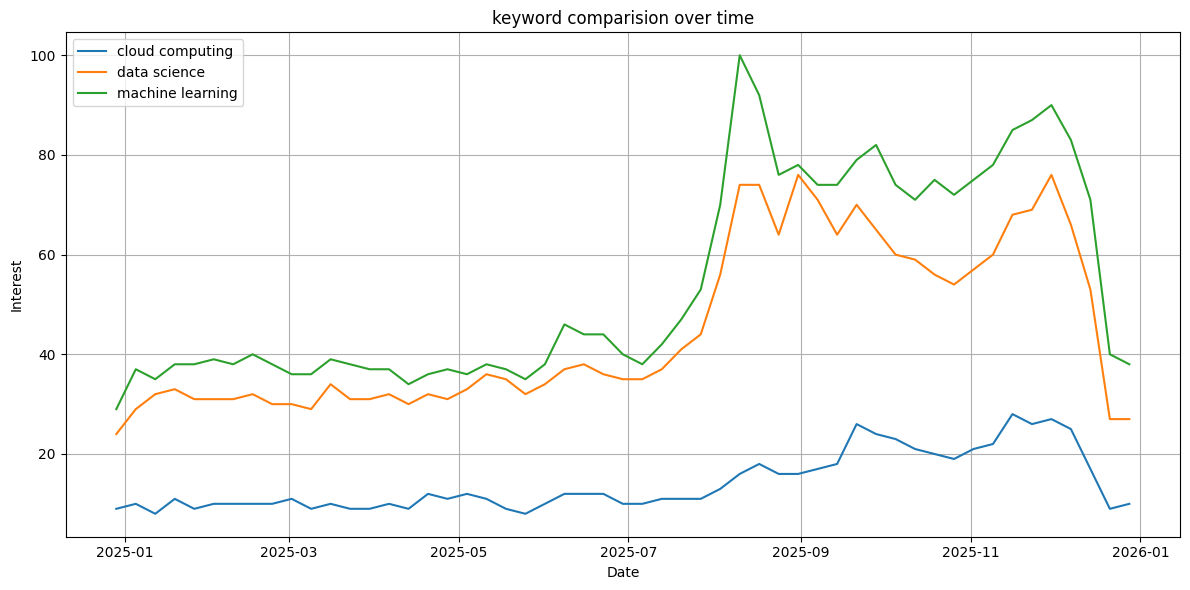

In [20]:
compare_df = pytrends.interest_over_time()

plt.figure(figsize = (12,6))
for kw in kw_list:
    plt.plot(compare_df.index,compare_df[kw], label = kw)

plt.title("keyword comparision over time")
plt.xlabel("Date")
plt.ylabel("Interest")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()